<a href="https://colab.research.google.com/github/danielhinsching/Harve-School/blob/main/EDA_Aula3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configuração inicial

Rode as células abaixo para instalar as bibliotecas e carregar os dados que vamos usar na aula.

In [ ]:
!pip install pandas
!pip install matplotlib

In [ ]:
import pandas as pd

Dataset auxiliar que vamos usar nos exemplos da primeira parte da aula:

In [ ]:
dados = {
    'id_familia': [1, 2, 3, 4, 5, 6, 7, 8],
    'tipo_casa': ["apartamento", "casa", "casa", "kitnet", "sobrado", "apartamento", "apartamento", "casa"],
    'tamanho_casa': ["pequeno", "médio", "grande", "pequeno", "médio", "grande", "grande", "pequeno"],
    'n_cartoes': [4, 6, 6, 7, 8, 7, 8, 10],
    'tamanho_familia': [2, 2, 4, 4, 5, 5, 6, 6],
    'renda_familiar': [14, 16, 14, 17, 18, 21, 17, 25],
    'num_automoveis': [1, 2, 2, 1, 3, 2, 1, 3],
    'distanciacentro': [22.2, 3, 31, 2, 1, 12, 2, 4]
}

df = pd.DataFrame(dados)
df.head()

,id_familia,tipo_casa,tamanho_casa,n_cartoes,tamanho_familia,renda_familiar,num_automoveis,distanciacentro
0,1,apartamento,pequeno,4,2,14,1,22.2
1,2,casa,médio,6,2,16,2,3.0
2,3,casa,grande,6,4,14,2,31.0
3,4,kitnet,pequeno,7,4,17,1,2.0
4,5,sobrado,médio,8,5,18,3,1.0


Dataset da FIFA — carregado direto da internet:

In [ ]:
dffifa = pd.read_csv('https://www.harve.com.br/praticas/fifaplayers_pt.csv')
dffifa.head()

,id,nome,idade,nacionalidade,pontuação geral,potencial,time,valor,remuneração,perna de preferência,...,emprestado de,validade do contrato,altura,peso,controle de bola,arrancada,agilidade,equilíbrio,energia,força
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Esquerda,...,NaN,2021,5'7,159lbs,96.0,91.0,91.0,95.0,72.0,59.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Direita,...,NaN,2022,6'2,183lbs,94.0,89.0,87.0,70.0,88.0,79.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Direita,...,NaN,2022,5'9,150lbs,95.0,94.0,96.0,84.0,81.0,49.0
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Direita,...,NaN,2020,6'4,168lbs,42.0,57.0,60.0,43.0,43.0,64.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Direita,...,NaN,2023,5'11,154lbs,91.0,78.0,79.0,77.0,90.0,75.0


---

# Regressão Linear

Até agora vimos correlação — que mede a **força** da relação entre duas variáveis.
A regressão linear vai um passo além: ela encontra a **equação da reta** que melhor descreve essa relação.

Com ela você consegue fazer previsões. Se eu sei quantas horas alguém pratica esporte, consigo estimar o humor dessa pessoa.

## Descoberta guiada

Considere os dados abaixo. Antes de calcular qualquer coisa, dê uma olhada nas colunas:
- **Horas_esporte** e **Humor** — o que você acha que vai acontecer?
- **Idade** e **Filhos** — parece ter alguma relação?

Vamos calcular a correlação e plotar o pairplot para ver se o seu chute estava certo.

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
dados = {
    'Horas_esporte': [0, 0.5, 1, 1.5, 2, 2.5, 3],
    'Humor': [5, 5.4, 6.9, 7.2, 8.3, 8.5, 9.5],
    'Idade': [32, 51, 24, 24, 39, 57, 21],
    'Filhos': [1, 2, 1, 3, 1, 2, 4]
}

df_humor = pd.DataFrame(dados)
df_humor

,Horas_esporte,Humor,Idade,Filhos
0,0.0,5.0,32,1
1,0.5,5.4,51,2
2,1.0,6.9,24,1
3,1.5,7.2,24,3
4,2.0,8.3,39,1
5,2.5,8.5,57,2
6,3.0,9.5,21,4


A matriz de correlação mostra um número entre -1 e 1 para cada par de colunas. Quanto mais próximo de 1 ou -1, mais forte a relação linear:

In [ ]:
df_humor.corr()

,Horas_esporte,Humor,Idade,Filhos
Horas_esporte,1.000000,0.986542,-0.032709,0.601338
Humor,0.986542,1.000000,-0.130402,0.524829
Idade,-0.032709,-0.130402,1.000000,-0.295769
Filhos,0.601338,0.524829,-0.295769,1.000000


O pairplot mostra essa mesma informação de forma visual. Pares com relação linear clara formam uma linha diagonal nos gráficos de dispersão:

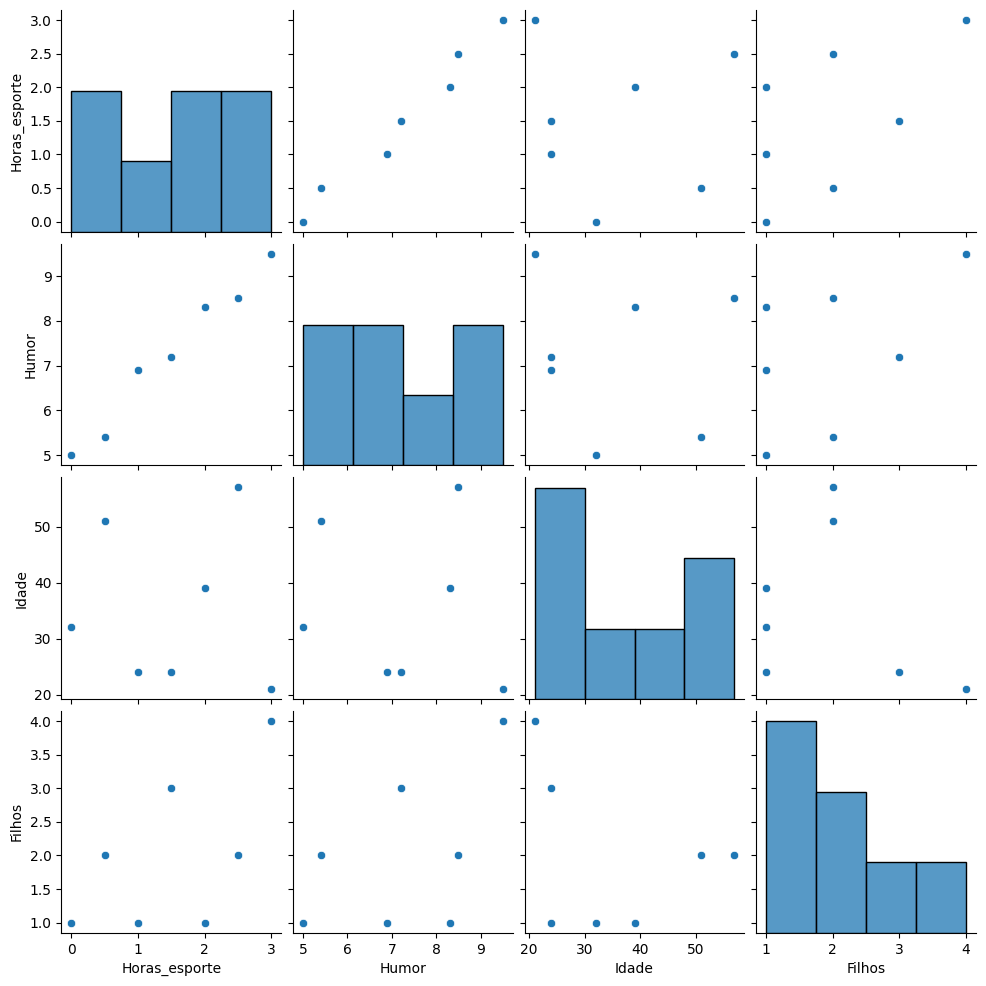

In [ ]:
sns.pairplot(df_humor)

---

## Hands On — FIFA

Agora é com você. Usando o dataset da FIFA, descubra quais atributos dos jogadores têm relação linear com a **reputação internacional**.

O código abaixo calcula a correlação entre todas as colunas numéricas e filtra só as que têm correlação maior que 0.3 com `reputação internacional`. Execute célula por célula e observe o que aparece.

In [ ]:
dffifa_corr = dffifa.corr(numeric_only=True)

In [ ]:
filtro = dffifa_corr > 0.3

In [ ]:
colunas_de_interesse = list(
    filtro.loc[filtro['reputação internacional'] == True]['reputação internacional'].index
)

In [ ]:
dffifa_corr[dffifa_corr > 0.3].loc[colunas_de_interesse, colunas_de_interesse]

,pontuação geral,potencial,reputação internacional
pontuação geral,1.000000,0.660939,0.499491
potencial,0.660939,1.000000,0.372993
reputação internacional,0.499491,0.372993,1.000000


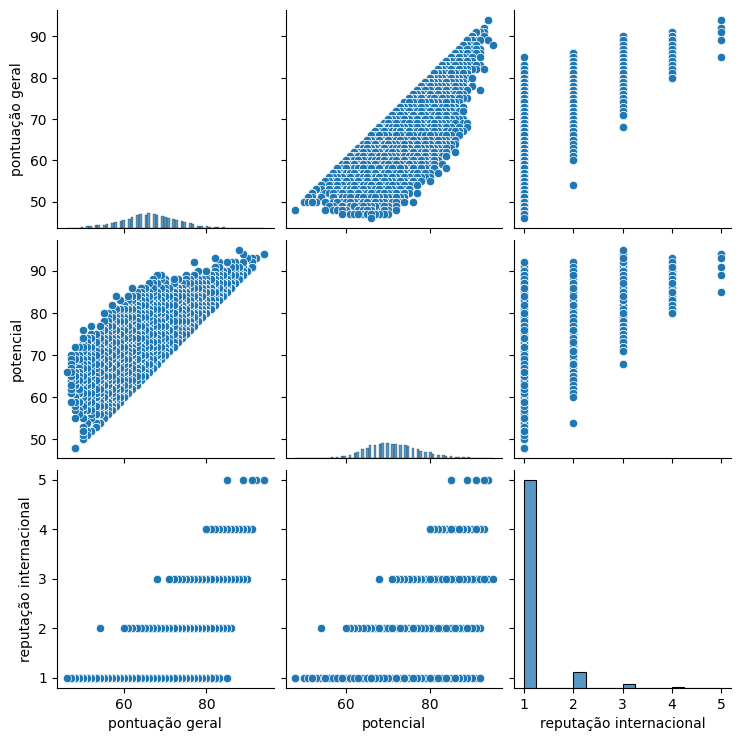

In [ ]:
sns.pairplot(dffifa[colunas_de_interesse])

---

# Gerando a Expressão Linear

Agora vamos calcular a equação da reta usando o scikit-learn.

A ideia é simples: dado um conjunto de pontos (X, Y), o modelo encontra os valores de **b₀** e **b₁** na equação:

> **Y = b₀ + b₁ × X**

Onde:
- **b₁** é o coeficiente angular (o quanto Y muda para cada unidade de X)
- **b₀** é o intercepto (o valor de Y quando X = 0)

## Descoberta guiada

Vamos encontrar a equação da reta para `Horas_esporte` → `Humor`.

Antes de rodar o modelo, repare que uma das células vai inserir um valor ausente (`None`) no DataFrame. Isso é proposital — dados reais sempre têm valores faltando, e você precisa saber tratar isso antes de treinar qualquer modelo.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [ ]:
df_humor

,Horas_esporte,Humor,Idade,Filhos
0,0.0,5.0,32,1
1,0.5,5.4,51,2
2,1.0,6.9,24,1
3,1.5,7.2,24,3
4,2.0,8.3,39,1
5,2.5,8.5,57,2
6,3.0,9.5,21,4


Inserindo um valor ausente para simular dados reais:

In [ ]:
df_humor.iloc[2, 0] = None

Antes de treinar o modelo, precisamos remover as linhas com valores ausentes. O `.dropna()` faz isso. Veja como ele funciona em cada coluna separadamente:

In [ ]:
df_humor[['Horas_esporte']].dropna()

,Horas_esporte
0,0.0
1,0.5
3,1.5
4,2.0
5,2.5
6,3.0


In [ ]:
df_humor[['Humor']].dropna()

,Humor
0,5.0
1,5.4
2,6.9
3,7.2
4,8.3
5,8.5
6,9.5


Agora criamos o DataFrame de treino, sem nenhum valor faltando:

In [ ]:
df_humor_regressao = df_humor[['Horas_esporte', 'Humor']].dropna()
df_humor_regressao

,Horas_esporte,Humor
0,0.0,5.0
1,0.5,5.4
3,1.5,7.2
4,2.0,8.3
5,2.5,8.5
6,3.0,9.5


Separamos X (variável que a gente conhece) e Y (variável que queremos prever):

In [ ]:
X = df_humor_regressao[['Horas_esporte']]
Y = df_humor_regressao[['Humor']]

Criamos o modelo e treinamos com os dados:

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X, Y)

LinearRegression()

Agora pegamos os coeficientes que o modelo encontrou. Com eles você consegue montar a equação da reta:

In [ ]:
model.coef_, model.intercept_

(array([[1.54161491]]), array([4.8757764]))

Usando o modelo para prever os valores de Y para os X que já conhecemos:

In [ ]:
model.predict(X)

array([[4.8757764 ],
       [5.64658385],
       [7.18819876],
       [7.95900621],
       [8.72981366],
       [9.50062112]])

In [ ]:
df_humor.iloc[2, 0] = None

E aqui vem a parte mais interessante: prever para um valor **novo**, que não estava nos dados de treino. Se alguém pratica 1.8 horas de esporte, qual seria o humor esperado?

In [ ]:
model.predict([[1.8]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[7.65068323]])

---

## Hands On — FIFA

Sua vez. Usando o dataset da FIFA, encontre a equação da regressão linear entre **agilidade** (X) e **arrancada** (Y).

Siga os mesmos passos da descoberta guiada: trate os valores ausentes, separe X e Y, treine o modelo e leia os coeficientes.

O resultado esperado é algo próximo de: **arrancada = 0,81 × agilidade + 12,56**

In [ ]:
dffifa

,id,nome,idade,nacionalidade,pontuação geral,potencial,time,valor,remuneração,perna de preferência,...,emprestado de,validade do contrato,altura,peso,controle de bola,arrancada,agilidade,equilíbrio,energia,força
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Esquerda,...,NaN,2021,5'7,159lbs,96.0,91.0,91.0,95.0,72.0,59.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Direita,...,NaN,2022,6'2,183lbs,94.0,89.0,87.0,70.0,88.0,79.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Direita,...,NaN,2022,5'9,150lbs,95.0,94.0,96.0,84.0,81.0,49.0
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Direita,...,NaN,2020,6'4,168lbs,42.0,57.0,60.0,43.0,43.0,64.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Direita,...,NaN,2023,5'11,154lbs,91.0,78.0,79.0,77.0,90.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,€60K,€1K,Direita,...,NaN,2019,5'9,134lbs,43.0,54.0,60.0,76.0,40.0,47.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,€60K,€1K,Direita,...,NaN,2020,6'3,170lbs,40.0,41.0,38.0,52.0,43.0,67.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,€60K,€1K,Direita,...,NaN,2021,5'8,148lbs,44.0,70.0,50.0,58.0,55.0,32.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,€60K,€1K,Direita,...,NaN,2019,5'10,154lbs,52.0,61.0,52.0,71.0,40.0,48.0


In [ ]:
print("predizer arrancada com base na agilidade")

predizer arrancada com base na agilidade


In [ ]:
dffifa_regressao = dffifa[['arrancada', 'agilidade']].dropna()
dffifa_regressao

,arrancada,agilidade
0,91.0,91.0
1,89.0,87.0
2,94.0,96.0
3,57.0,60.0
4,78.0,79.0
...,...,...
18202,54.0,60.0
18203,41.0,38.0
18204,70.0,50.0
18205,61.0,52.0


In [ ]:
model_fifa = LinearRegression()

In [ ]:
model_fifa.fit(dffifa_regressao[['agilidade']], dffifa_regressao[['arrancada']])

LinearRegression()

In [ ]:
model_fifa.coef_, model_fifa.intercept_

(array([[0.81971282]]), array([12.55935468]))

In [ ]:
print("arrancada = 0,81*agilidade + 12,56")

arrancada = 0,81*agilidade + 12,56


Agora vamos visualizar: os pontos azuis são os dados reais, os laranjas são os valores previstos pelo modelo. Uma boa regressão tem os laranjas formando uma linha reta sobre a nuvem de pontos azuis:

In [ ]:
dffifa_regressao['y_pred'] = model_fifa.predict(dffifa_regressao[['agilidade']])
dffifa_regressao

,arrancada,agilidade,y_pred
0,91.0,91.0,87.153222
1,89.0,87.0,83.874370
2,94.0,96.0,91.251786
3,57.0,60.0,61.742124
4,78.0,79.0,77.316668
...,...,...,...
18202,54.0,60.0,61.742124
18203,41.0,38.0,43.708442
18204,70.0,50.0,53.544996
18205,61.0,52.0,55.184421


In [ ]:
import matplotlib.pyplot as plt

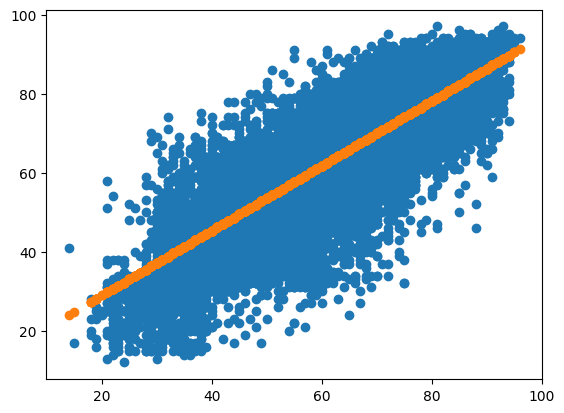

In [ ]:
plt.scatter(dffifa_regressao[['agilidade']], dffifa_regressao[['arrancada']])
plt.scatter(dffifa_regressao[['agilidade']], dffifa_regressao[['y_pred']], c='C1')
plt.show()

---

# Teste A/B — Tamanho de Amostra

Antes de rodar qualquer teste A/B, você precisa responder uma pergunta fundamental:
**quantas pessoas preciso observar para que o resultado seja confiável?**

A fórmula é:

> **n = (Z × σ / e)²**

Onde:
- **Z** = valor da tabela Z para o nível de confiança desejado (95% → Z = 1.96)
- **σ** = desvio padrão estimado da população (quando não se sabe, usa-se 0.5 — valor mais conservador)
- **e** = margem de erro máxima aceitável

Quanto menor a margem de erro que você quer, maior precisa ser a amostra.

## Descoberta guiada

Uma empresa quer saber se a mudança no layout do site gerou resultado.
Eles querem uma margem de erro de **2%** com **95% de confiança**.

Qual deve ser o tamanho da amostra?

a) 5287  
b) 2401  
c) 8547  
d) 925

Calcule abaixo e confira:

In [ ]:
Z = 1.96      # 95% de confiança
sigma = 0.5   # desvio padrão conservador
e = 0.02      # margem de erro: 2%

n = (Z * sigma / e) ** 2
n

2401.0

---

# Bootcamp — Olist

Chegou a hora de trabalhar com dados reais de uma empresa brasileira.

A **Olist** é o maior marketplace B2B do Brasil: conecta pequenos vendedores a grandes canais de venda. O dataset está disponível publicamente no Kaggle e contém pedidos, clientes, vendedores, produtos e avaliações.

Alguns detalhes importantes sobre os dados:
- Um pedido pode ter vários itens
- Cada item pode ter sido vendido por um vendedor diferente
- Os nomes das lojas foram anonimizados com nomes das casas de Game of Thrones

O dataset completo está em: https://harve.com.br/praticas/olist/olist_csv.rar  
Baixe na sua máquina antes de rodar — processar direto da URL é lento.

In [39]:
import os

# Verifica se o comando unrar está disponível e instala se necessário
if os.system('which unrar') != 0:
    print('Instalando unrar...')
    os.system('apt-get update && apt-get install -y unrar')
    print('unrar instalado.')

# Extrai o conteúdo do arquivo .rar
!unrar x /content/olist_csv.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/olist_csv.rar

Extracting  olist_customers_dataset.csv                                   11%  OK 
Extracting  olist_geolocation_dataset.csv                                 22% 33% 44% 46%  OK 
Extracting  olist_order_items_dataset.csv                                 57%  OK 
Extracting  olist_order_payments_dataset.csv                              64%  OK 
Extracting  olist_order_reviews_dataset.csv                               75% 79%  OK 
Extracting  olist_orders_dataset.csv                                      90% 97%  OK 
Extracting  olist_products_dataset.csv                                    99%  OK 
Extracting  olist_sellers_dataset.csv                                     99%  OK 
Extracting  product_category_name_translation.csv                        100%  OK 
All OK


## Carregando os datasets

Cada arquivo CSV é uma tabela diferente. Vamos carregar todos:

In [40]:
dfolist_customers_dataset = pd.read_csv('/content/olist_customers_dataset.csv')
dfolist_geolocation_dataset = pd.read_csv('/content/olist_geolocation_dataset.csv')
dfolist_order_items_dataset = pd.read_csv('/content/olist_order_items_dataset.csv')
dfolist_order_payments_dataset = pd.read_csv('/content/olist_order_payments_dataset.csv')
dfolist_order_reviews_dataset = pd.read_csv('/content/olist_order_reviews_dataset.csv')
dfolist_orders_dataset = pd.read_csv('/content/olist_orders_dataset.csv')
dfolist_products_dataset = pd.read_csv('/content/olist_products_dataset.csv')
dfolist_sellers_dataset = pd.read_csv('/content/olist_sellers_dataset.csv')
dfproduct_category_name_translation = pd.read_csv('/content/product_category_name_translation.csv')

## Juntando as tabelas

Para saber o **preço mediano por estado**, precisamos cruzar três tabelas:
- `order_items` tem o preço de cada item
- `orders` liga o item ao cliente
- `customers` tem o estado de cada cliente

Fazemos isso com três `merge()` encadeados. Leia cada célula com calma e tente entender o que está sendo unido em cada etapa:

In [ ]:
pedidos_a = pd.merge(
    dfolist_order_items_dataset,
    dfolist_products_dataset[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)
pedidos_a.head()

In [ ]:
pedidos_b = pd.merge(
    pedidos_a,
    dfolist_orders_dataset[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)
pedidos_b.head()

In [ ]:
pedidos_novo = pd.merge(
    pedidos_b,
    dfolist_customers_dataset[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)
pedidos_novo.head()

Com tudo numa tabela só, podemos responder: qual é o preço mediano dos pedidos em cada estado?

In [ ]:
moda_categoria_produto = pedidos_novo.groupby('customer_state')['price'].median()
moda_categoria_produto

In [ ]:
# Nota: esta célula pode dar erro se 'pedidos_frete_estado' não estiver definido.
# Ignore por enquanto — vamos resolver isso juntos na aula.
total_vendas_por_categoria_c_frete = pedidos_frete_estado.groupby('customer_state')['freight_value'].mean()
total_vendas_por_categoria_c_frete

E para visualizar a distribuição de preços por estado — incluindo onde estão os outliers:

In [ ]:
sns.boxplot(data=pedidos_novo, x='customer_state', y='price')
plt.title('Variação de Preço por Estado')
plt.xlabel('Estado')
plt.ylabel('Preço')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()